In [60]:
from util.load import DataLoader
from api.weather import OpenMeteoAPI
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os

In [65]:
loader = DataLoader('../data')
weather = OpenMeteoAPI()

results = loader.get_all_market_results('kxhighny', max_days=275)
weather_forecast = weather.get_daily_weather_forecast('kxhighny')

In [62]:
daily_data = loader.load_daily_data('kxhighny', max_days=300)

Loading kxhighny for 2025-06-05: 100%|██████████| 294/294 [00:01<00:00, 276.02it/s]


In [63]:
kalshi_implied = {}
for date, df in daily_data.items():
    kalshi_implied[date] = df[df['time_to_strike'] < 60000].iloc[0]['kalshi_fair']

In [66]:
df = {
    'date': [],
    'kalshi': [],
    'implied': []
}
for date, v in results.items():
    forecast = weather_forecast[weather_forecast['time'] == date]
    if forecast.empty:
        continue
    for c in forecast.columns:
        if c == 'time':
            continue
        if c not in df:
            df[c] = []
        df[c].append(forecast[c].values[0])
    df['date'].append(date)
    df['kalshi'].append(v)
    df['implied'].append(kalshi_implied[date])
    
df = pd.DataFrame(df)
df.drop(columns=['date'])

,kalshi,implied,temperature_2m_max_bom_access_global,daylight_duration_bom_access_global,precipitation_hours_bom_access_global,precipitation_probability_max_bom_access_global,wind_speed_10m_max_bom_access_global,temperature_2m_max_cma_grapes_global,daylight_duration_cma_grapes_global,precipitation_hours_cma_grapes_global,...,daylight_duration_dmi_seamless,precipitation_hours_dmi_seamless,precipitation_probability_max_dmi_seamless,wind_speed_10m_max_dmi_seamless,temperature_2m_max_gfs_seamless,daylight_duration_gfs_seamless,precipitation_hours_gfs_seamless,precipitation_probability_max_gfs_seamless,wind_speed_10m_max_gfs_seamless,forecast
0,77.5,77.370,76.5,46582.54,0.0,0,6.5,74.8,46579.55,0.0,...,46572.75,0.0,0,11.2,78.6,46576.95,0.0,0.0,16.4,1350.171177
1,76.5,76.900,76.7,46425.00,0.0,0,13.3,74.8,46422.17,0.0,...,46415.72,0.0,0,12.7,75.9,46419.70,0.0,0.0,17.3,1321.214260
2,78.5,76.186,76.8,46267.59,1.0,0,8.6,75.3,46264.91,0.0,...,46258.80,0.0,0,11.9,77.1,46262.58,0.0,0.0,12.7,1337.028329
3,76.5,74.078,73.5,46110.39,14.0,0,20.9,71.8,46107.87,6.0,...,46102.11,12.0,0,24.5,76.3,46105.67,2.0,0.0,19.6,1308.919774
4,69.5,70.060,69.1,45953.51,0.0,0,16.9,69.1,45951.14,0.0,...,45945.73,0.0,0,22.3,71.2,45949.07,0.0,0.0,21.6,1226.876638
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270,66.5,66.574,67.0,53694.67,0.0,0,18.7,67.9,53684.37,0.0,...,53660.86,0.0,0,21.0,68.0,53675.37,0.0,2.0,23.4,NaN
271,70.5,72.552,71.5,53761.96,0.0,0,12.6,70.1,53751.59,0.0,...,53727.91,0.0,0,10.5,74.2,53742.52,0.0,9.0,18.0,NaN
272,78.5,79.076,77.4,53826.23,0.0,0,11.5,75.4,53815.79,0.0,...,53791.95,0.0,0,8.6,81.9,53806.66,0.0,1.0,14.4,NaN
273,82.5,82.581,82.6,53887.40,0.0,0,14.0,80.2,53876.89,0.0,...,53852.89,0.0,0,13.3,85.3,53867.70,0.0,0.0,20.0,NaN


In [67]:
forecast_names = [f for f in df.columns if f.startswith('temperature_')]

def compute_forecast_std(row):
    return np.std([row[f] for f in forecast_names])

df['forecast_std'] = df.apply(compute_forecast_std, axis=1)

In [68]:
def remove_outliers(df, features, quantile_range=(0.01, 0.99)):
    mask = np.ones(len(df), dtype=bool)
    for f in features:
        mask = mask & (df[f] >= df[f].quantile(quantile_range[0])) & (df[f] <= df[f].quantile(quantile_range[1]))
    return df[mask]

In [69]:
df['best_forecast_delta'] = df['temperature_2m_max_best_match'] - df['kalshi']
df['implied_delta'] = df['implied'] - df['kalshi']

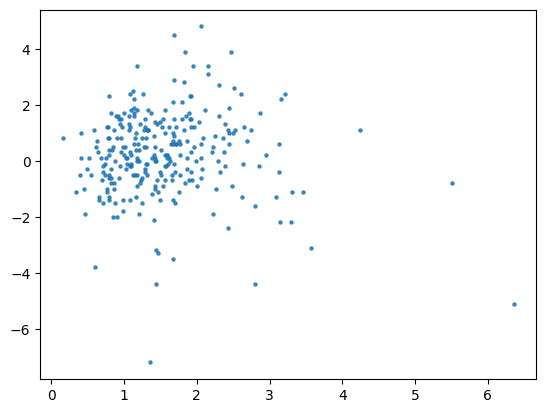

In [70]:
plt.scatter(df['forecast_std'], df['best_forecast_delta'], alpha=0.8, s=5)
plt.show()

In [71]:
df = remove_outliers(df, ['best_forecast_delta'])

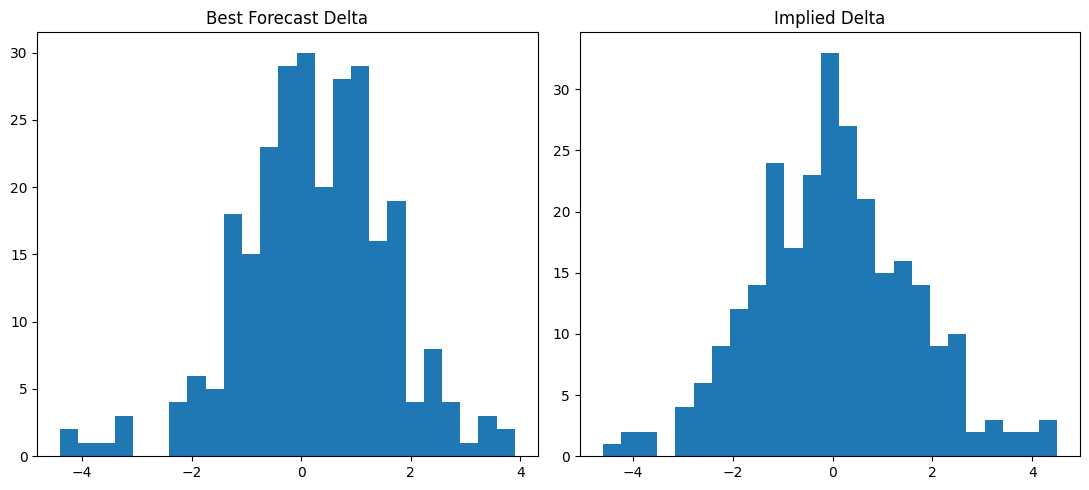

0.25350553505535056 0.03481918819188182
1.355174130866307 1.6071278684984973


In [72]:
fig, ax = plt.subplots(1, 2, figsize=(11, 5))

ax[0].hist(df['best_forecast_delta'], bins=25)
ax[0].set_title('Best Forecast Delta')
ax[1].hist(df['implied_delta'], bins=25)
ax[1].set_title('Implied Delta')

plt.tight_layout()
plt.show()
print(df['best_forecast_delta'].mean(), df['implied_delta'].mean())
print(df['best_forecast_delta'].std(), df['implied_delta'].std())

In [36]:
print(df['best_forecast_delta'].iloc[-14:].mean())

1.400000000000001


In [16]:
auto_corr = df['best_forecast_delta'].autocorr(lag=1)
print(auto_corr)

0.19667445305783057


In [30]:
dates = sorted(os.listdir('../runtime'))
forecast_trends = {}

forecast_trends = []
for date in dates:
    with open(f'../runtime/{date}', 'r') as f:
        data = f.readlines()
    
    forecasts = []
    for line in data:
        line = json.loads(line)['trade']
        if 'forecast' in line:
            forecast = line['forecast']
        if 'day_forecast_high' in line:
            forecast = line['day_forecast_high']
        if len(forecasts) > 0 and forecasts[-1] == forecast:
            continue
        forecasts.append(forecast)
    forecast_trends.append(forecasts[-1] - forecasts[0])

print(forecast_trends)
print(np.mean(forecast_trends))

[0.7000000000000028, 1.9000000000000057, 0.8000000000000114, 1.5, 2.4000000000000057, 0.09999999999999432, -0.7000000000000028, 0.9500000000000028]
0.9562500000000025
